<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/PC05_RNAseq_Differential_Expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PC05 — RNA-seq Differential Expression

Template workflow for normalized expression and case/control differential analysis. For publication, substitute the generated matrix with a properly normalized count matrix and use DESeq2/edgeR in R for count-based inference.

In [1]:
# @title Colab setup
!pip -q install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels lifelines networkx umap-learn openpyxl requests

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 2.6 MB/s eta 0:00:00
Environment ready.


In [2]:
# Synthetic demonstration matrix; replace with real patient-matched expression
genes = [f"GENE_{i:04d}" for i in range(500)]
samples = [f"P{i:03d}" for i in range(1,21)]
expr = pd.DataFrame(np.random.lognormal(2, 1, (500,20)), index=genes, columns=samples)
groups = pd.Series(["Tumor"]*10 + ["Control"]*10, index=samples)
print(expr.shape)


(500, 20)


In [3]:
from scipy.stats import ttest_ind
res=[]
for g in expr.index:
    a=expr.loc[g, groups=="Tumor"]
    b=expr.loc[g, groups=="Control"]
    stat,p=ttest_ind(a,b,equal_var=False)
    res.append((g, a.mean(), b.mean(), np.log2((a.mean()+1e-8)/(b.mean()+1e-8)), p))
de=pd.DataFrame(res, columns=["gene","tumor_mean","control_mean","log2FC","p"])
de["FDR"]=__import__("statsmodels.stats.multitest", fromlist=["multipletests"]).multipletests(de.p, method="fdr_bh")[1]
display(de.sort_values("FDR").head(20))


,gene,tumor_mean,control_mean,log2FC,p,FDR
396,GENE_0396,12.229728,22.267714,-0.864561,0.249012,0.90011
254,GENE_0254,14.771355,9.083509,0.701481,0.484304,0.90011
255,GENE_0255,9.131564,18.772300,-1.039672,0.319882,0.90011
256,GENE_0256,6.732100,9.524165,-0.500536,0.176401,0.90011
257,GENE_0257,10.749838,25.601785,-1.251930,0.320012,0.90011
372,GENE_0372,27.432833,6.946562,1.981533,0.103296,0.90011
373,GENE_0373,10.901293,16.678198,-0.613464,0.474574,0.90011
375,GENE_0375,9.856545,21.689376,-1.137835,0.217699,0.90011
390,GENE_0390,12.164459,7.105516,0.775661,0.316834,0.90011
391,GENE_0391,11.234413,8.627298,0.380944,0.338793,0.90011


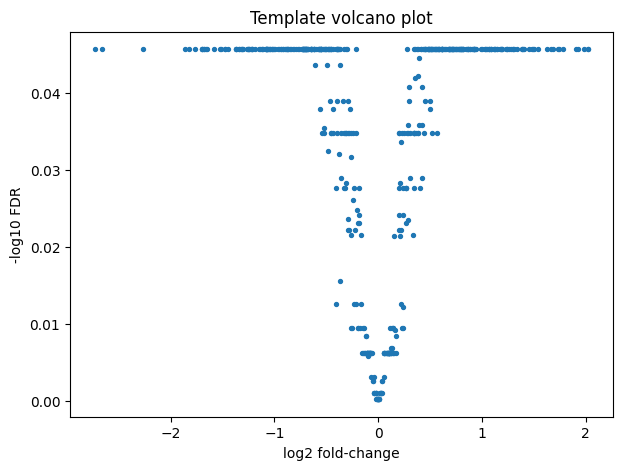

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(de["log2FC"], -np.log10(de["FDR"]+1e-300), s=8)
plt.xlabel("log2 fold-change"); plt.ylabel("-log10 FDR"); plt.title("Template volcano plot")
plt.show()
